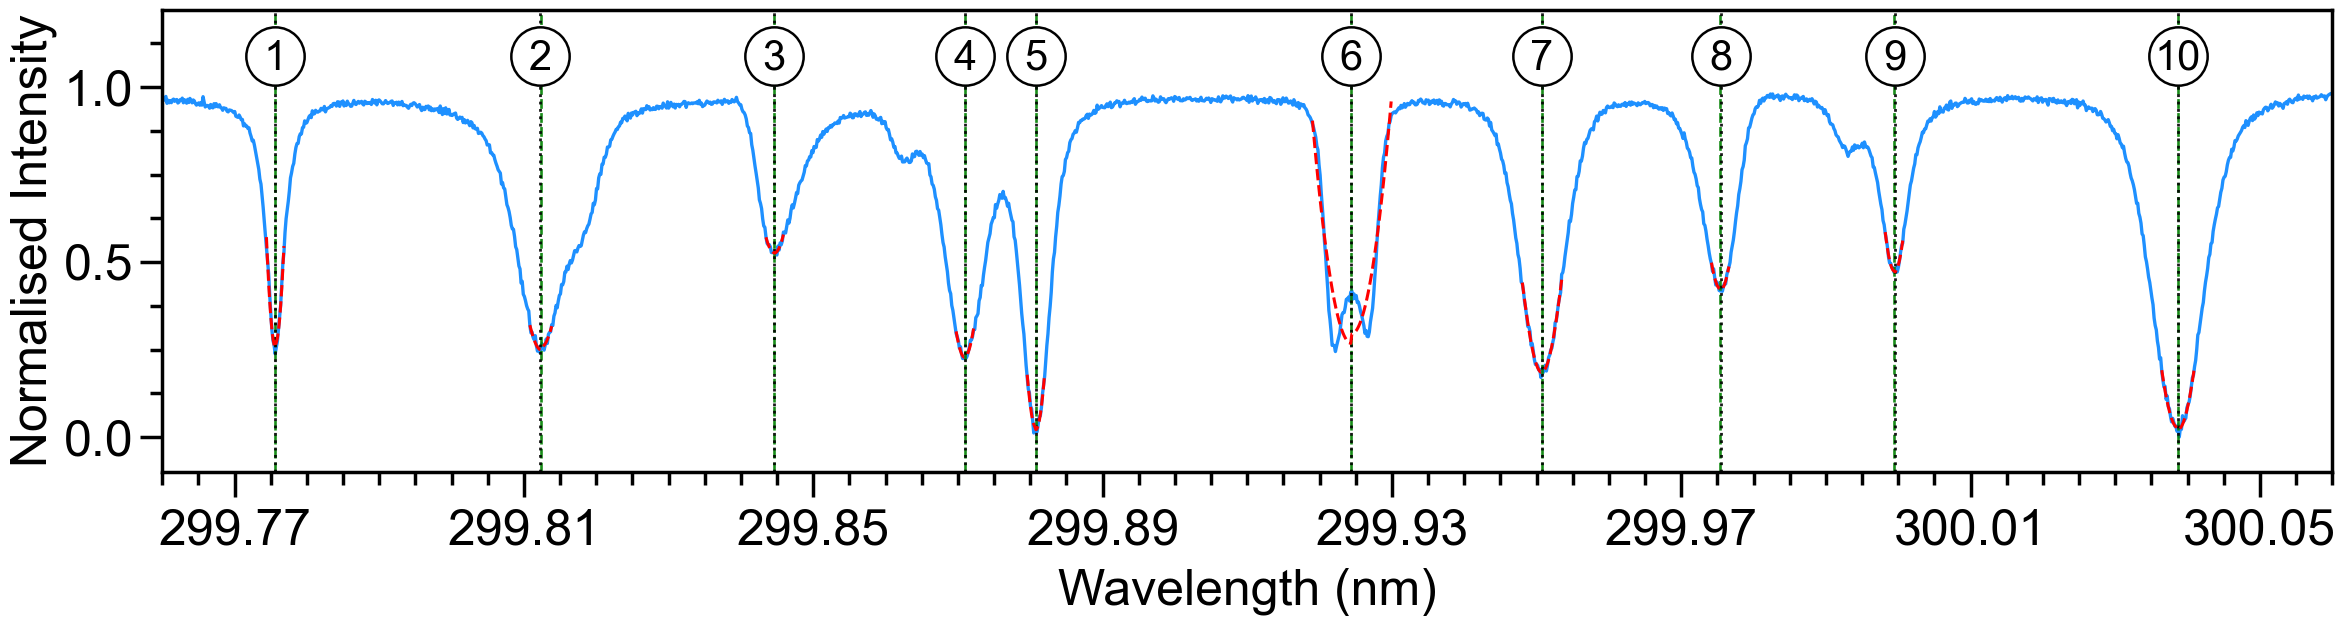

GPL Ghostscript 10.06.0 (2025-09-09)
Copyright (C) 2025 Artifex Software, Inc.  All rights reserved.
This software is supplied under the GNU AGPLv3 and comes with NO WARRANTY:
see the file COPYING for details.
Processing pages 1 through 1.
Page 1
PDF saved in CMYK format as 'Figures/Figure1_synthetic_spectrum_fitted_cores.pdf'
Line 1: 0.01 pm   (0.007 km/s)
Line 2: 0.10 pm   (0.103 km/s)
Line 3: 0.05 pm   (0.049 km/s)
Line 4: 0.01 pm   (0.008 km/s)
Line 5: 0.03 pm   (0.033 km/s)
Line 6: 0.03 pm   (0.029 km/s)
Line 7: 0.01 pm   (0.005 km/s)
Line 8: 0.02 pm   (0.018 km/s)
Line 9: 0.01 pm   (0.009 km/s)
Line 10: 0.02 pm   (0.019 km/s)


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Figure 1: LineFit validation on the synthetic near-UV (NUV) testbed
====================================================================

Purpose
-------
This script is a *verification / regression* harness for the WaLSA LineFit pipeline
using the synthetic dataset produced by `synthetic_nuv_testbed.fits`.

It performs three steps, in order:

1) Load the synthetic FITS testbed:
   - spectra cube + wavelength/time axes
   - rest wavelengths (LAMBDA0)
   - ground-truth time-dependent centres (CENTER_TRUE) and velocities (V_TRUE)
   - split/emission driver arrays for the complex split+emission line

2) Run WaLSA LineFit on a single spectrum:
   - Calls `linefit(...)` from `WaLSAlib`
   - Writes per-line extracted parameters to CSV
   - Writes fitted spectra to a FITS file

3) Reconstruct and plot the validation figure:
   - Rebuilds the internally used smoothed/normalised spectrum (blue curve)
   - Overlays the fitted model segments from the saved fitted FITS (red dashed)
   - Overlays fitted centres from the CSV (green dashed verticals)
   - Overlays ground-truth centres for the chosen time step (black dotted)
   - Prints per-line |truth − fitted| in picometres and km/s

Important conventions / assumptions
-----------------------------------
• Synthetic testbed layout:
    `spectra` has shape (nt, nw), i.e. time is the first axis.
  The LineFit API uses the argument name `pixel`, but in this synthetic test
  the same argument is intentionally used as a *time index* selecting one
  1D spectrum from `spectra`.

• Reference wavelengths:
    `refwavelength` passed to LineFit is the REST wavelengths (LAMBDA0),
    not the time-dependent truth centres (CENTER_TRUE). This is required to
    interpret fitted centres as Doppler shifts relative to rest wavelengths.

• Saved fitted spectra:
    LineFit stores fitted model segments in *intensity-inverted space* (i.e.
    absorption minima become peaks). For plotting in standard intensity space,
    we convert back with:  I_fit ≈ 1 − fitted_inv.

Inputs (edit here)
------------------
- fits_path: path to `synthetic_nuv_testbed.fits`
- indx: time index to validate (default: 0)

Outputs (side effects)
----------------------
Created by LineFit:
  - extracted_parameters_<date_identifier>_pixel_<indx>.csv
  - fitted_spectra_<date_identifier>_pixel_<indx>.fits

Created by this script:
  - synthetic_spectrum_fitted_cores.pdf

Dependencies
------------
numpy, matplotlib, astropy, scipy (uniform_filter1d), WaLSAtools (WaLSA_save_pdf),
WaLSAlib (linefit)

Author / context
----------------
WaLSA Team / Shahin Jafarzadeh (2026)

Notes for repository use
------------------------
- This script is designed to be run from the directory that contains
  `synthetic_nuv_testbed.fits`, or with `fits_path` adjusted accordingly.
- The plotting style is intentionally *frozen* to keep Figure 1 identical
  to the manuscript version. 

"""

import os

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from matplotlib.ticker import AutoMinorLocator
from scipy.ndimage import uniform_filter1d

from WaLSAlib import linefit   # type: ignore
from WaLSAtools import WaLSAtools, WaLSA_save_pdf  # type: ignore

# =============================================================================
# 1) Read synthetic FITS testbed
# =============================================================================
fits_path = "synthetic_nuv_testbed.fits"
with fits.open(fits_path) as hdul:
    # Primary HDU: spectra cube
    spectra        = np.asarray(hdul[0].data)                  # (nt, nw)

    # Axes + truth products
    wavelengths    = np.asarray(hdul["WAVELENGTH"].data)       # (nw,)
    time_s         = np.asarray(hdul["TIME"].data)             # (nt,)
    lambda0_nm     = np.asarray(hdul["LAMBDA0"].data)          # (10,)
    v_true_kms     = np.asarray(hdul["V_TRUE"].data)           # (10, nt)
    center_true_nm = np.asarray(hdul["CENTER_TRUE"].data)      # (10, nt)
    split_strength = np.asarray(hdul["SPLIT_STRENGTH"].data)    # (nt,)
    emis_strength  = np.asarray(hdul["EMIS_STRENGTH"].data)     # (nt,)

# =============================================================================
# 2) Choose the spectrum to fit (here: time index into spectra[time, :])
# =============================================================================
indx = 0

I = spectra[indx]                            # (nw,)
true_center = center_true_nm[:, indx]        # (10,) truth line centres at this time step

# IMPORTANT:
# refwavelength MUST be the REST wavelengths (lambda0), not the time-dependent centres,
# for the intended WaLSA behaviour / velocity inference.
refwavelength = lambda0_nm.copy()            # (10,)

# Human-readable labels (kept simple; not used in fitting logic)
element = np.array([f"Line {i}" for i in range(10)], dtype=object)

# Per-line half-window settings (index-bin units; as used in the manuscript)
per_line_window_size = [10, 10, 10, 10, 10, 28, 18, 10, 10, 20]
per_line_min_halfwin = [8, 10, 8, 8, 8, 14, 10, 8, 8, 12]
per_line_max_halfwin = [14, 13, 12, 12, 12, 36, 22, 14, 12, 24]

# =============================================================================
# 3) Run LineFit for this selected time index
# =============================================================================
vlos_fit, inten_fit = linefit(
    spectra=spectra,
    fit_func="asymmetric_voigt",
    num_iterations=20,
    date_identifier="date_id",
    refwavelength=refwavelength,
    wavelengths=wavelengths,
    element=element,
    pixel=indx,
    window_size=14,
    per_line_window_size=per_line_window_size,
    per_line_min_halfwin=per_line_min_halfwin,
    per_line_max_halfwin=per_line_max_halfwin,
    plot_result=False,
    smoothing_window=1,
    return_vlos_intensity=True,
    adaptive_window=True,
    write_csv=True,
    save_fitted_spectra=True,
    use_coarse_centers=True,
    close_pairs=[(3, 4)],
    reversal_lines=[5],
    silent=True,
)

# =============================================================================
# 4) Helper functions (behaviour-preserving)
# =============================================================================
def _sanitize_1d_spectrum(original_spectrum: np.ndarray) -> np.ndarray:
    """
    Replace non-finite values (NaN/inf) in a 1D spectrum with interpolated values.

    Interpolation is performed along wavelength index. If fewer than two finite
    samples exist, the function falls back to constant fill or zeros.
    """
    s = np.asarray(original_spectrum, dtype=np.float64).copy()
    bad = ~np.isfinite(s)
    if bad.any():
        good_idx = np.flatnonzero(~bad)
        if good_idx.size >= 2:
            s[bad] = np.interp(np.flatnonzero(bad), good_idx, s[good_idx])
        elif good_idx.size == 1:
            s[bad] = s[good_idx[0]]
        else:
            s[:] = 0.0
    return s


def _robust_normalise_01(arr: np.ndarray) -> np.ndarray:
    """
    Robustly normalise an array to [0, 1] using min/max.

    Includes a safe fallback for degenerate or non-finite ranges to avoid NaNs/Infs.
    """
    a = np.asarray(arr, dtype=np.float64)
    a0 = np.nanmin(a)
    a1 = np.nanmax(a)
    den = a1 - a0
    if (not np.isfinite(den)) or (den <= 0.0):
        out = np.zeros_like(a, dtype=np.float64)
        out[0] = 1e-6
        return out
    return (a - a0) / den


w = np.asarray(wavelengths, dtype=float)
original_spectrum = np.asarray(I, dtype=float)

csv_path  = f"extracted_parameters_date_id_pixel_{indx}.csv"
fits_path = f"fitted_spectra_date_id_pixel_{indx}.fits"

# =============================================================================
# 5) Read fitted centres (CSV) and fitted spectrum (FITS)
# =============================================================================
# Expected CSV columns:
# ["Spatial Pixel","Element","Ref Wavelength (nm)","Fitted centre (nm)",
#  "LOS Velocity (km/s)","Line Core Intensity"]
rows = np.genfromtxt(csv_path, delimiter=",", names=True, dtype=None, encoding="utf-8")

# Filter robustly by pixel index (here: indx used as time index)
pix = indx
mask_pix = (rows["Spatial_Pixel"] == pix) if "Spatial_Pixel" in rows.dtype.names else np.ones(len(rows), dtype=bool)

# genfromtxt often sanitises column names; locate the fitted-centre column robustly
col_candidates = ["Fitted_centre_nm", "Fitted_centre__nm_", "Fitted_centre_(nm)", "Fitted_centre_nm_"]
fitted_col = None
for c in col_candidates:
    if c in rows.dtype.names:
        fitted_col = c
        break
if fitted_col is None:
    # fallback: any column name containing "Fitted" and "centre"
    for c in rows.dtype.names:
        if ("Fitted" in c) and ("centre" in c):
            fitted_col = c
            break
if fitted_col is None:
    raise ValueError(f"Could not find fitted-centre column in CSV. Columns: {rows.dtype.names}")

fitted_centres = np.asarray(rows[fitted_col][mask_pix], dtype=float)

# FITS output: fitted model segments in intensity-inverted space
with fits.open(fits_path) as hdul_fit:
    fitted_inv = np.asarray(hdul_fit[0].data)

if fitted_inv.ndim == 2:
    # In single-spectrum mode, the first row corresponds to the saved output
    last_final_fitted = fitted_inv[0].astype(float)
elif fitted_inv.ndim == 1:
    last_final_fitted = fitted_inv.astype(float)
else:
    raise ValueError(f"Unexpected fitted FITS shape: {fitted_inv.shape}")

# =============================================================================
# 6) Reconstruct the internally smoothed/normalised spectrum (for plotting)
# =============================================================================
spec01 = _robust_normalise_01(_sanitize_1d_spectrum(original_spectrum))

# NOTE: keep identical to the LineFit call above
smoothing_window = 1
last_smoothed_spectrum = uniform_filter1d(spec01, size=int(smoothing_window))

# =============================================================================
# 7) Plot Figure 1 (style frozen to match manuscript)
# =============================================================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'font.size': 37,
    'axes.titlesize': 36,
    'axes.labelsize': 36,
    'xtick.labelsize': 36,
    'ytick.labelsize': 36,
    'legend.fontsize': 36,
    'figure.titlesize': 37,
    'axes.grid': False,
    'grid.alpha': 0.5,
    'grid.linestyle': '--',
    'font.weight': 500,
    'axes.titleweight': 500,
    'axes.labelweight': 500
})

plt.rc('axes', linewidth=2.5)
plt.rc('lines', linewidth=1.5)

fig = plt.figure(figsize=(28, 6), constrained_layout=False)

# Blue: smoothed, normalised spectrum
plt.plot(w, last_smoothed_spectrum, color="DodgerBlue", lw=2.4)

# Red dashed: fitted model segments (convert back from inverted space: I_fit ≈ 1 − fitted_inv)
valid_indices = np.where(np.isfinite(last_final_fitted))[0]
if valid_indices.size > 0:
    ranges = np.split(valid_indices, np.where(np.diff(valid_indices) > 1)[0] + 1)
    for rr in ranges:
        x_fit = w[rr]
        y_fit = 1.0 - last_final_fitted[rr]
        if x_fit.size > 0:
            plt.plot(x_fit, y_fit, linestyle="--", color="red", lw=2.2, zorder=5)

# Green dashed: fitted centres from CSV
for xc in fitted_centres:
    if np.isfinite(xc):
        plt.axvline(float(xc), linestyle="--", color="green", alpha=0.9, lw=1.9)

# Black dotted: truth centres for this time step
for rw in true_center:
    plt.axvline(float(rw), linestyle=":", color="black", alpha=0.9, lw=2.0)

plt.tick_params(axis="y", which="major", length=16, width=2.5, pad=5)
plt.tick_params(axis="x", which="major", length=18, width=2.5, pad=5)
plt.tick_params(axis="x", which="major", pad=8)
plt.tick_params(axis="both", which="minor", length=9, width=2.5)
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator(8))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.set_xlim(299.760, 300.060)
ax.set_xticks(np.arange(299.770, 300.060, 0.04))
plt.xlabel("Wavelength (nm)", labelpad=10)
plt.ylabel("Normalised Intensity", labelpad=5)

ax.set_ylim(-0.10, 1.22)
ylim = (-0.10, 1.22)

# Numbered circle labels at truth centres (line IDs 1..10)
y_circle = ylim[1] - 0.100 * (ylim[1] - ylim[0])
y_text   = ylim[1] - 0.105 * (ylim[1] - ylim[0])

for j, rw in enumerate(true_center):
    if np.isfinite(rw):
        plt.plot(
            float(rw), y_circle,
            marker="o",
            markersize=42,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=1.8,
            linestyle="None",
            zorder=6,
        )
        plt.text(
            float(rw), y_text, f"{j+1}",
            fontsize=30,
            ha="center",
            va="center",
            color="black",
            zorder=7,
        )

plt.show()

# Save the figure as a single PDF (Frontiers-friendly)
pdf_path = 'Figures/Figure1_synthetic_spectrum_fitted_cores.pdf'
WaLSA_save_pdf(fig, pdf_path, color_mode='CMYK', dpi=300, bbox_inches='tight', pad_inches=0.15)

# =============================================================================
# 8) Move generated CSV/FITS outputs into ./Files/
# =============================================================================
out_dir = "Files"
os.makedirs(out_dir, exist_ok=True)

# Move (overwrite if already exists)
for src in (csv_path, fits_path):
    if os.path.exists(src):
        dst = os.path.join(out_dir, os.path.basename(src))
        if os.path.exists(dst):
            os.remove(dst)
        os.rename(src, dst)

# =============================================================================
# 9) Print absolute centre offsets (truth − fit) in pm and km/s
# =============================================================================
# NOTE: This assumes fitted_centres are ordered the same way as truth_center (line 0..9),
# which is the intended behaviour when the LineFit CSV is written line-by-line.
C_KMS = 299792.458
for i, (dpm, dv) in enumerate(
    zip(
        np.abs(true_center - fitted_centres) * 1e3,                           # nm -> pm
        np.abs(C_KMS * (true_center - fitted_centres) / refwavelength),       # km/s
    )
):
    print(f"Line {i+1}: {dpm:.2f} pm   ({dv:.3f} km/s)")